In [1]:
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
import snapatac2 as snap
import numpy as np
import pandas as pd
import os
import scanpy.external as sce
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import scale
import scipy.sparse as sp


In [2]:
import warnings
warnings.filterwarnings("ignore")


In [2]:
DMR_H5AD_PATH = "/data2st1/junyi/output/atac1112/3REGIONS_dmr.h5ads"
PEAK_H5AD_PATH = "/data2st1/junyi/output/atac1112/3REGIONS_peak.h5ads"

if os.path.exists(DMR_H5AD_PATH):
    print(f"Loading existing dmr_mat from {DMR_H5AD_PATH}")
    dmr_mat = sc.read_h5ad(DMR_H5AD_PATH)
else:
    print("Creating dmr_mat from snapATAC2...")
    adata_concat = snap.read_dataset('/data2st1/junyi/output/atac1112/doublet_filtered.h5ads/_dataset.h5ads')
    df_meta_all = pd.read_csv('/data2st1/junyi/output/atac1112/ATACSC_3REGION_ALL_L2annoated.csv', index_col=0)
    df_l3l4 = pd.read_csv('/data2st1/junyi/output/atac1112/iterative/annotated_l3l4.csv', index_col=0)
    df_meta_all = df_meta_all.merge(df_l3l4[['celltype.L3','celltype.L4']], left_index=True, right_index=True, how='left')
    
    %time dmr_mat = snap.pp.make_peak_matrix(adata_concat, peak_file='/data2st1/junyi/output/atac1112/cCRE/dmr_3regions_ext.bed')
    
    dmr_mat.write(DMR_H5AD_PATH)
    adata_concat.close()
    print(f"Saved dmr_mat to {DMR_H5AD_PATH}")

Loading existing dmr_mat from /data2st1/junyi/output/atac1112/3REGIONS_dmr.h5ads


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


# Compute npeaks_on / ngeneson for dmr_mat (if not already present)
Equivalent to `cdr2 <- colSums(assay(sca) > 0); colData(sca)$ngeneson <- scale(cdr2)` for scRNA-seq.
- `npeaks_on`: number of peaks with non-zero insertion count per cell
- `npeaks_on_scaled` / `ngeneson`: z-score across cells

In [3]:
if "ngeneson" in dmr_mat.obs.columns and dmr_mat.obs["ngeneson"].notna().any():
    print("ngeneson already exists in dmr_mat.obs, skipping chunk computation.")
else:
    print("Computing npeaks_on / ngeneson from adata_peak...")
    adata_peak = sc.read_h5ad(PEAK_H5AD_PATH, backed='r')
    adata_peak_mem = adata_peak  # .to_memory() if hasattr(adata_peak, "to_memory") else adata_peak
    adata_peak_mem_obs = adata_peak_mem.obs.copy()

    X = adata_peak_mem.X
    n_obs = adata_peak_mem.shape[0]
    npeaks_on = np.zeros(n_obs, dtype=np.int64)

    chunk_size = 10_000
    for start in range(0, n_obs, chunk_size):
        end = min(start + chunk_size, n_obs)
        chunk = X[start:end]
        if sp.issparse(chunk):
            npeaks_on[start:end] = np.asarray((chunk > 0).sum(axis=1)).ravel()
        else:
            npeaks_on[start:end] = (chunk > 0).sum(axis=1)

    adata_peak_mem_obs["npeaks_on"] = npeaks_on.astype(int)
    npeaks_on_scaled = scale(npeaks_on, with_mean=True, with_std=True)
    adata_peak_mem_obs["npeaks_on_scaled"] = npeaks_on_scaled

    # Merge into dmr_mat.obs by index
    df_to_merge = adata_peak_mem_obs[["npeaks_on", "npeaks_on_scaled"]].copy()
    df_to_merge = df_to_merge.reindex(dmr_mat.obs.index)
    dmr_mat.obs["npeaks_on"] = df_to_merge["npeaks_on"].values
    dmr_mat.obs["npeaks_on_scaled"] = df_to_merge["npeaks_on_scaled"].values
    dmr_mat.obs["ngeneson"] = dmr_mat.obs["npeaks_on_scaled"].values
    print("Computed and merged npeaks_on / ngeneson into dmr_mat.obs")

ngeneson already exists in dmr_mat.obs, skipping chunk computation.


In [4]:
# Quick sanity check
print(dmr_mat.obs[["npeaks_on", "npeaks_on_scaled", "ngeneson"]].describe())

           npeaks_on  npeaks_on_scaled      ngeneson
count  176318.000000      1.763180e+05  1.763180e+05
mean    17443.191274     -1.624853e-16 -1.624853e-16
std     10332.193747      1.000003e+00  1.000003e+00
min       851.000000     -1.605878e+00 -1.605878e+00
25%      9039.000000     -8.134008e-01 -8.134008e-01
50%     16175.000000     -1.227421e-01 -1.227421e-01
75%     24349.000000      6.683797e-01  6.683797e-01
max     65503.000000      4.651475e+00  4.651475e+00


# Merge additional metadata from adata_peak (celltype.L2.refined, expriment, etc.)

In [5]:
extra_meta_cols = ["celltype.L2.refined", "expriment", "experiment", "celltype.L2", "region", "condition"]
need_extra = any(c not in dmr_mat.obs.columns for c in extra_meta_cols)

if need_extra:
    print("Loading adata_peak for extra metadata...")
    adata_peak = sc.read_h5ad(PEAK_H5AD_PATH, backed='r')
    adata_peak_mem = adata_peak
    adata_peak_mem_obs = adata_peak_mem.obs.copy()

    present_cols = [c for c in extra_meta_cols if c in adata_peak_mem_obs.columns]
    print("Available extra metadata columns:", present_cols)

    if present_cols:
        df_to_merge = adata_peak_mem_obs[present_cols].copy()
        df_to_merge = df_to_merge.reindex(dmr_mat.obs.index)
        for col in present_cols:
            dmr_mat.obs[col] = df_to_merge[col].values
        print(f"Merged {len(present_cols)} extra metadata columns into dmr_mat.obs")
else:
    print("All extra metadata columns already present, skipping adata_peak load.")

Loading adata_peak for extra metadata...
Available extra metadata columns: ['celltype.L2.refined', 'expriment', 'celltype.L2']
Merged 3 extra metadata columns into dmr_mat.obs


In [13]:
dmr_mat.X.max()

np.uint32(139)

# QC on dmr_mat
- `npeaks_on_dmr`: number of DMRs with non-zero insertion count per cell (rows of dmr_mat).
- `ncells_on_dmr`: number of cells with non-zero insertion count per DMR (columns of dmr_mat).
- `npeaks_on_dmr_scaled` and `ncells_on_dmr_scaled`: z-score of the above.
- Save the per-peak QC to `dmr_mat.var` for downstream filtering.

In [14]:
# Number of non-zero peaks per cell
X_dmr = dmr_mat.X
if sp.issparse(X_dmr):
    npeaks_on_dmr = np.asarray((X_dmr > 0).sum(axis=1)).ravel()
else:
    npeaks_on_dmr = (X_dmr > 0).sum(axis=1)

# Number of non-zero cells per peak
if sp.issparse(X_dmr):
    ncells_on_dmr = np.asarray((X_dmr > 0).sum(axis=0)).ravel()
else:
    ncells_on_dmr = (X_dmr > 0).sum(axis=0)

In [15]:
dmr_mat.obs["npeaks_on_dmr"] = npeaks_on_dmr.astype(int)
dmr_mat.obs["npeaks_on_dmr_scaled"] = scale(npeaks_on_dmr, with_mean=True, with_std=True)

dmr_mat.var["ncells_on_dmr"] = ncells_on_dmr.astype(int)
dmr_mat.var["ncells_on_dmr_scaled"] = scale(ncells_on_dmr, with_mean=True, with_std=True)

In [16]:
# Quick summary
print("=== dmr_mat.obs (per cell) ===")
print(dmr_mat.obs["npeaks_on_dmr"].describe())
print("\n=== dmr_mat.var (per peak) ===")
print(dmr_mat.var["ncells_on_dmr"].describe())

=== dmr_mat.obs (per cell) ===
count    152117.000000
mean        719.405471
std         377.286375
min         200.000000
25%         416.000000
50%         650.000000
75%         950.000000
max        2488.000000
Name: npeaks_on_dmr, dtype: float64

=== dmr_mat.var (per peak) ===
count     75872.000000
mean       1442.347664
std        2237.355223
min           0.000000
25%         533.000000
50%         987.000000
75%        1712.000000
max      107685.000000
Name: ncells_on_dmr, dtype: float64


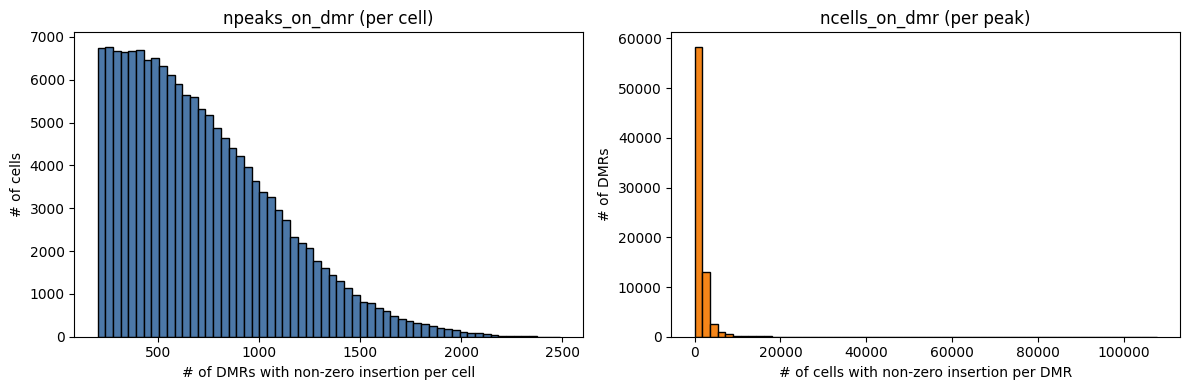

In [17]:
# Quick histogram to visualise the QC distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(dmr_mat.obs["npeaks_on_dmr"], bins=60, color="#4C78A8", edgecolor="black")
axes[0].set_title("npeaks_on_dmr (per cell)")
axes[0].set_xlabel("# of DMRs with non-zero insertion per cell")
axes[0].set_ylabel("# of cells")

axes[1].hist(dmr_mat.var["ncells_on_dmr"], bins=60, color="#F58518", edgecolor="black")
axes[1].set_title("ncells_on_dmr (per peak)")
axes[1].set_xlabel("# of cells with non-zero insertion per DMR")
axes[1].set_ylabel("# of DMRs")

plt.tight_layout()
plt.show()

In [18]:
# Save the per-peak QC table for downstream filtering
dmr_mat.var[["ncells_on_dmr", "ncells_on_dmr_scaled"]].to_csv(
    "/data2st1/junyi/output/atac1112/3REGIONS_dmr_var_qc.csv"
)
dmr_mat.obs[["npeaks_on_dmr", "npeaks_on_dmr_scaled"]].to_csv(
    "/data2st1/junyi/output/atac1112/3REGIONS_dmr_obs_qc.csv"
)
print("Saved dmr QC tables.")

Saved dmr QC tables.


# Filter cells and peaks based on QC metrics
- Keep cells with `npeaks_on_dmr >= 200`
- Keep peaks (DMRs) with `ncells_on_dmr >= 3`

In [19]:
print(f"Before filtering: {dmr_mat.n_obs} cells, {dmr_mat.n_vars} DMRs")

# Filter cells (obs)
cells_keep = dmr_mat.obs["npeaks_on_dmr"] >= 200
dmr_mat = dmr_mat[cells_keep, :].copy()

# Filter peaks (var)
peaks_keep = dmr_mat.var["ncells_on_dmr"] >= 3
dmr_mat_filtered = dmr_mat[:, peaks_keep].copy()

print(f"After filtering:  {dmr_mat_filtered.n_obs} cells, {dmr_mat_filtered.n_vars} DMRs")

Before filtering: 152117 cells, 75872 DMRs


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


After filtering:  152117 cells, 74477 DMRs


In [20]:
dmr_mat_filtered.write_h5ad(f"/data2st1/junyi/output/atac1112/3REGIONS_dmr_filtered.h5ads")